# 1. Otsu's Thresholding

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from otsu import (
        compute_histogram,
        load_image, 
        _normalize_histogram, 
        p_helper, 
        mu_helper,
        otsu_threshold,
        otsu_binarize,
        custom_binarization
    )
import matplotlib.pyplot as plt
import numpy as np

In [19]:
def show_image(image:np.ndarray, title:str):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [20]:
def show_histogram(histogram:np.ndarray):
    bin_edges = np.arange(256)

    plt.figure(figsize=(8, 4))
    plt.title("Grayscale Histogram")
    plt.xlabel("Pixel Intensity (0-255)")
    plt.ylabel("Number of Pixels")

    plt.bar(bin_edges, histogram, color='blue', width=1.0)

    plt.xlim([0, 255])

    plt.show()

## 1.1. Histogram Calculation

In [21]:
image = load_image(path="./data/hello.png")
histogram = compute_histogram(image=image)

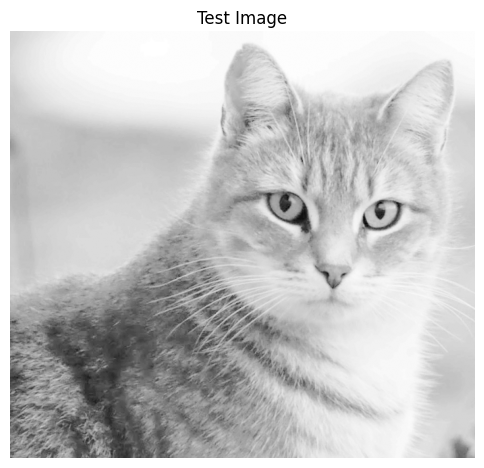

In [22]:
show_image(image, "Test Image")

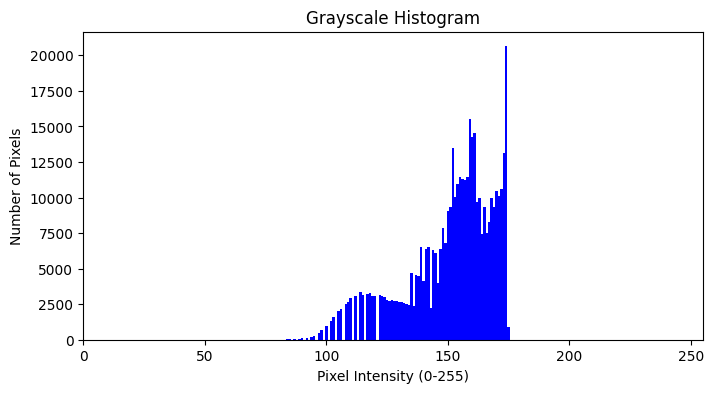

In [23]:
show_histogram(histogram=histogram)

## 1.2. Calculate $p_0$ and $p_1$

In [24]:
prob = _normalize_histogram(histogram=histogram)
p0, p1 = p_helper(prob=prob, theta=250)
print(f"p0 = {p0}, p1 = {p1}")

p0 = 1.0, p1 = 0.0


## 1.3. Calculate $\mu_0$ and $\mu_1$

In [25]:
m0, m1 = mu_helper(prob=prob, theta=120, p0=p0, p1=p1)
print(f"m0 = {m0}, m1 = {m1}")

m0 = 10.353013448218846, m1 = 0


## 1.4. Calculate the Optimal Threshold

In [26]:
optimal_threshold = otsu_threshold(histogram)
print(optimal_threshold)

143


## 1.5. Otsu Image Binarization

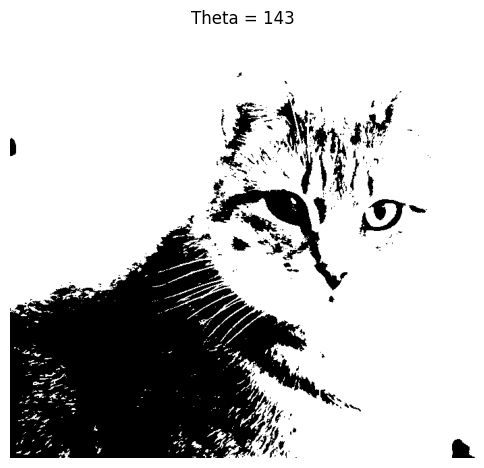

In [27]:
binarized, theta = otsu_binarize(image)
show_image(binarized, f"Theta = {theta}")

## 1.6. Custom Image Binarization

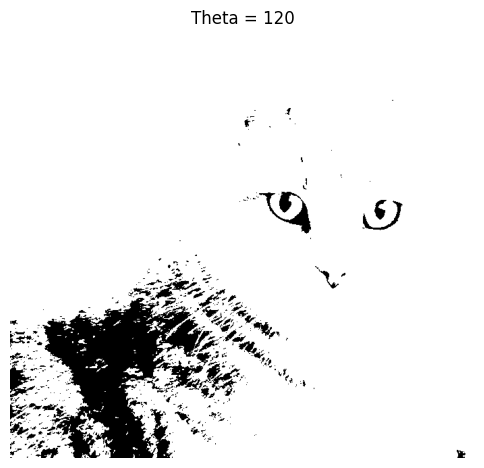

In [28]:
binarized, theta = custom_binarization(image, 120)
show_image(binarized, f"Theta = {theta}")